In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import few
from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux
from few.utils.geodesic import get_fundamental_frequencies
from few.utils.constants import YRSID_SI
import os
import sys

# Changing directory
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

# Configuration
use_gpu = True
force_backend = "cuda12x"
dt = 10.0  # seconds
T = 2.0  # years (use 2 years for full evolution)

# Waveform generator setup
inspiral_kwargs = {
    "func": 'KerrEccEqFlux',
    "DENSE_STEPPING": 0,
    "include_minus_m": False,
}

amplitude_kwargs = {"force_backend": force_backend}
Ylm_kwargs = {"force_backend": force_backend}
sum_kwargs = {
    "force_backend": force_backend,
    "pad_output": True,
}

waveform_gen = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux,
    frame='detector',
    inspiral_kwargs=inspiral_kwargs,
    amplitude_kwargs=amplitude_kwargs,
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs,
    use_gpu=use_gpu
)




In [ ]:
# Source parameters 
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 11.7 
e0 = 0.4
xI0 = 1.0
dist = 0.9  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5


params = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

In [3]:
def get_viewing_angles(qS, phiS, qK, phiK):
    """Transform from the detector frame to the source  frame"""
    cqS = np.cos(qS)
    sqS = np.sin(qS)
    cphiS = np.cos(phiS)
    sphiS = np.sin(phiS)
    cqK = np.cos(qK)
    sqK = np.sin(qK)
    cphiK = np.cos(phiK)
    sphiK = np.sin(phiK)
    # sky location vector
    R = np.array([sqS * cphiS, sqS * sphiS, cqS])
    # spin vector
    S = np.array([sqK * cphiK, sqK * sphiK, cqK])
    print(R,S)
    # get viewing angles
    phi = -np.pi / 2.0  # by definition of source frame
    theta = np.arccos(-np.dot(R, S))  # normalized vector

    return (theta, phi)

In [4]:
theta, phi = get_viewing_angles(qS, phiS, qK, phiK)
theta, phi

[ 1.2246468e-16  0.0000000e+00 -1.0000000e+00] [0. 0. 1.]


(np.float64(0.0), -1.5707963267948966)

In [5]:
theta*180/np.pi  

np.float64(0.0)

In [6]:
print("Generating waveform...")
# 
h = waveform_gen(*params, T=T, dt=dt)

Generating waveform...


In [7]:
h

array([ 3.78558229e-22+5.25167711e-22j,  4.31145032e-22+4.63272508e-22j,
        4.73068274e-22+3.98268492e-22j, ...,
       -5.77410313e-22+6.06811358e-22j, -4.16338180e-22+7.31394141e-22j,
       -2.28035916e-22+8.14898210e-22j], shape=(6311630,))

In [8]:
h_real = h.real
h_real

array([ 3.78558229e-22,  4.31145032e-22,  4.73068274e-22, ...,
       -5.77410313e-22, -4.16338180e-22, -2.28035916e-22],
      shape=(6311630,))

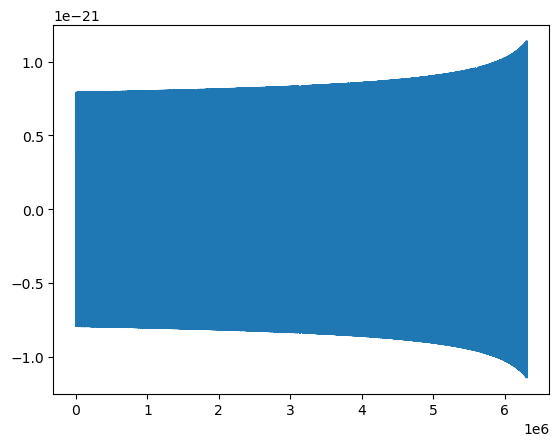

In [9]:
plt.plot(h_real.get())
plt.show()

In [10]:
import GWfuncs

gwf = GWfuncs.GravWaveAnalysis(T, dt)
gwf.rhostat(h)

array(96.98740604)

In [11]:
print(f"Signal length: {len(h_real)} samples")
print(f"Duration: {len(h_real) * dt / YRSID_SI:.2f} years")


Signal length: 6311630 samples
Duration: 2.00 years


In [12]:
# Generate trajectory to get fundamental frequencies
print("Computing fundamental frequencies...")
from few.trajectory.inspiral import EMRIInspiral
N_traj = 5000
delta_T = T*YRSID_SI/5000
traj_gen = EMRIInspiral(func='KerrEccEqFlux')
t_arr, p_arr, e_arr, x_arr, Phi_phi_arr, Phi_theta_arr, Phi_r_arr = traj_gen(
    m1, m2, a, p0, e0, xI0, T=T, dt=dt, upsample=True,
    Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0
)

Computing fundamental frequencies...


In [13]:
from few.utils.utility import get_p_at_t

get_p_at_t(traj_module=traj_gen, t_out=T, traj_args=[m1, m2, a, e0, xI0])


11.606899362008043

In [14]:
p_arr, e_arr

(array([11.7       , 11.69999959, 11.69999917, ...,  5.62159697,
         5.62159237,  5.62158778], shape=(6311629,)),
 array([0.4       , 0.39999998, 0.39999996, ..., 0.12687824, 0.12687808,
        0.12687792], shape=(6311629,)))

In [15]:
len(p_arr)

6311629

In [16]:

# Get fundamental frequencies along trajectory
freqs_list = []
for p_val, e_val in zip(p_arr, e_arr):
    Om_phi, Om_theta, Om_r = get_fundamental_frequencies(a, p_val, e_val, xI0)
    freqs_list.append([Om_phi, Om_theta, Om_r])

freqs_list

[[0.01971368776220821, 0.019108341687235263, 0.015451845941009939],
 [0.019713689337112185, 0.019108343183883658, 0.01545184703159573],
 [0.019713690912014286, 0.019108344680520625, 0.015451848122172113],
 [0.019713692486921473, 0.019108346177170728, 0.015451849212759373],
 [0.019713694061824667, 0.01910834767382069, 0.015451850303346351],
 [0.019713695636715104, 0.01910834917045682, 0.01545185139392199],
 [0.01971369721163589, 0.019108350667113083, 0.015451852484513974],
 [0.019713698786543627, 0.019108352163756902, 0.015451853575095858],
 [0.019713700361440087, 0.01910835366039379, 0.01545185466567214],
 [0.01971370193633806, 0.019108355157038372, 0.015451855756254467],
 [0.01971370351124129, 0.019108356653691774, 0.015451856846843819],
 [0.019713705086149946, 0.019108358150337634, 0.015451857937427298],
 [0.01971370666105235, 0.01910835964698086, 0.015451859028008398],
 [0.01971370823597391, 0.01910836114363829, 0.015451860118600969],
 [0.019713709810886857, 0.019108362640287625, 0.

In [17]:
freqs_arr = np.array(freqs_list)
from few.utils.constants import MTSUN_SI
M = m1+m2
Msec = M * MTSUN_SI  # Total mass in seconds
freq_phi = freqs_arr[:, 0] / (2 * np.pi * Msec)  # Convert to Hz
freq_theta = freqs_arr[:, 1] / (2 * np.pi * Msec)
freq_r = freqs_arr[:, 2] / (2 * np.pi * Msec)

In [18]:
modes = [
    (l, m, n) 
    for l in range(2, 4) 
    for m in range(-l, l + 1)
    for n in range(-1,6)
]

# Compute mode frequencies
mode_freqs = []
for l, m, n in modes:
    f_mode = m * freq_phi + n * freq_r
    mode_freqs.append(f_mode)

In [19]:
modes_21 = [
    (2, m, 1) 
    for m in range(-2,3)
]
modes_21

[(2, -2, 1), (2, -1, 1), (2, 0, 1), (2, 1, 1), (2, 2, 1)]

In [20]:
len(modes), len(mode_freqs)

(84, 84)

In [21]:
## INCLUDE FOR ALL M 
# just np range 
# 

modes_l2= [
    (2, m, n) 
    for m in range(-2, 3)
    for n in range(-55,56)
]



modes_l3= [
    (3, m, n) 
    for m in range(-3, 4)
    for n in range(-55,56)
]

mode_freqs_l2 = []
for l, m, n in modes_l2:
    f_mode = m * freq_phi + n * freq_r
    mode_freqs_l2.append(f_mode)

mode_freqs_l3 = []
for l, m, n in modes_l3:
    f_mode = m * freq_phi + n * freq_r
    mode_freqs_l3.append(f_mode)

In [29]:
modes_l2_trunc= [
    (2, m, n) 
    for m in range(-2, 3)
    for n in range(-1,6)
]

# check snr

In [22]:
h_l2 = waveform_gen(*params, T=T, dt=dt, mode_selection = modes_l2, include_minus_mkn=False)
h_l3 = waveform_gen(*params, T=T, dt=dt, mode_selection = modes_l3, include_minus_mkn=False)

(ModeSelector) Warning: Mode selection is large. Instantiate class with mode selection rather than providing it at call time for better performance.
(ModeSelector) Warning: Mode selection is large. Instantiate class with mode selection rather than providing it at call time for better performance.


In [30]:
h_l2_trunc = waveform_gen(*params, T=T, dt=dt, mode_selection = modes_l2_trunc, include_minus_mkn=False)


In [23]:
snr_full = gwf.rhostat(h)
snr_full

array(96.98740604)

In [24]:
snr_l2 = gwf.rhostat(h_l2)
snr_l2 

array(91.72594939)

In [25]:
p_l2 = gwf.rhostat(h_l2)**2/gwf.rhostat(h)**2 * 100
p_l2

array(89.44452104)

In [31]:
snr_l2_trunc = gwf.rhostat(h_l2_trunc)
snr_l2_trunc

array(91.61409178)

In [32]:
p_l2_trunc = gwf.rhostat(h_l2_trunc)**2/gwf.rhostat(h)**2 * 100
p_l2_trunc

array(89.22650313)

In [26]:
snr_l3 = gwf.rhostat(h_l3)
snr_l3

array(5.09652229)

In [27]:
p_l3 = gwf.rhostat(h_l3)**2 /gwf.rhostat(h)**2 *100
p_l3

array(0.27613227)

In [28]:
p_l2+p_l3

array(89.72065331)

# check orthogonality

In [31]:
waveforms_per_group = []


In [32]:
groups = [
    [(2,-2,-1),(2,-1,-1),  (2,0,-1), (2,1,-1), (2,2,-1)],#0
    [(2,-2,0),(2,-1,0),  (2,0,0), (2,1,0), (2,2,0)],#1
    [(2,-2,1),(2,-1,1),  (2,0,1), (2,1,1), (2,2,1)],#2
    [(2,-2,2),(2,-1,2),  (2,0,2), (2,1,2), (2,2,2)],#3
    [(2,-2,3),(2,-1,3),  (2,0,3), (2,1,3), (2,2,3)],#4
    [(2,-2,4),(2,-1,4),  (2,0,4), (2,1,4), (2,2,4)],#5
    [(2,-2,5),(2,-1,5),  (2,0,5), (2,1,5), (2,2,5)],#6
]

In [33]:
# so i can make sure of the order we'll do it manually
h_neg1 = waveform_gen(*params,
    dt=dt,
    T=T,
    mode_selection=groups[0],  
    include_minus_mkn=False,
)

h_0 = waveform_gen(*params,
    dt=dt,
    T=T,
    mode_selection=groups[1],  
    include_minus_mkn=False,
)


h_1 = waveform_gen(*params,
    dt=dt,
    T=T,
    mode_selection=groups[2],  
    include_minus_mkn=False,
)

h_2 = waveform_gen(*params,
    dt=dt,
    T=T,
    mode_selection=groups[3],  
    include_minus_mkn=False,
)

h_3 = waveform_gen(*params,
    dt=dt,
    T=T,
    mode_selection=groups[4],  
    include_minus_mkn=False,
)

h_4 = waveform_gen(*params,
    dt=dt,
    T=T,
    mode_selection=groups[5],  
    include_minus_mkn=False,
)

h_5 = waveform_gen(*params,
    dt=dt,
    T=T,
    mode_selection=groups[6],  
    include_minus_mkn=False,
)

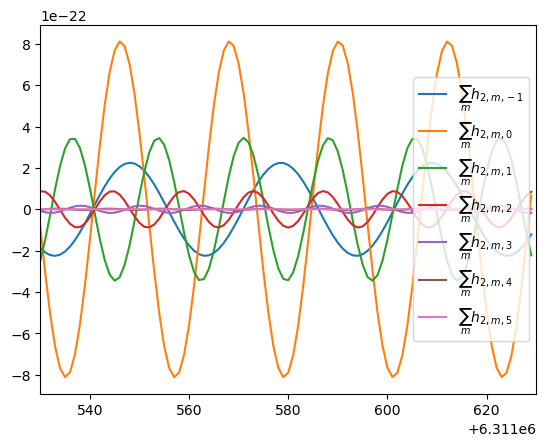

In [34]:
plt.plot(h_neg1.get().real, label=r'$\sum_m h_{2,m,-1}$')
plt.plot(h_0.get().real, label=r'$\sum_m h_{2,m,0}$')
plt.plot(h_1.get().real, label=r'$\sum_m h_{2,m,1}$')
plt.plot(h_2.get().real, label=r'$\sum_m h_{2,m,2}$')
plt.plot(h_3.get().real, label=r'$\sum_m h_{2,m,3}$')
plt.plot(h_4.get().real, label=r'$\sum_m h_{2,m,4}$')
plt.plot(h_5.get().real, label=r'$\sum_m h_{2,m,5}$')
plt.xlim(len(h_0)-100, len(h_0))
plt.legend(loc='right')
plt.show()

In [35]:
h_1, h_2, h_3, h_4, h_5

(array([-5.31667974e-24+2.47398702e-22j,  2.22233340e-23+2.46455911e-22j,
         4.94877715e-23+2.42456926e-22j, ...,
         1.01679623e-23-3.45577878e-22j, -1.13622616e-22-3.26523162e-22j,
        -2.22501095e-22-2.64614348e-22j]),
 array([9.45188896e-23+1.68855247e-22j, 1.17585284e-22+1.53686747e-22j,
        1.38258451e-22+1.35390238e-22j, ...,
        3.43776139e-23+8.14968539e-23j, 6.60007222e-23+5.88850280e-23j,
        8.48740888e-23+2.48980967e-23j]),
 array([ 1.08654820e-22+6.47131267e-23j,  1.18224499e-22+4.49068481e-23j,
         1.24217448e-22+2.37419713e-23j, ...,
        -1.26594245e-23-1.23194411e-23j, -1.71160242e-23-4.36691589e-24j,
        -1.70140315e-23+4.74863683e-24j]),
 array([7.51886186e-23+1.58842250e-24j, 7.39303403e-23-1.37896715e-23j,
        6.95601476e-23-2.85873212e-23j, ...,
        2.77551375e-24+1.17591397e-24j, 2.95419477e-24-5.99096028e-25j,
        2.09812495e-24-2.16425207e-24j]),
 array([ 3.72306466e-23-1.97841800e-23j,  3.15477409e-23-2.79691

In [36]:
waveforms = [h_neg1, h_0, h_1, h_2, h_3, h_4, h_5]                                                                                                                                               

# compute as matrixx
n = len(waveforms)
inner_product_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        hi_f = gwf.freq_wave(waveforms[i])
        hj_f = gwf.freq_wave(waveforms[j])
        inner_product_matrix[i,j] = gwf.inner(hi_f, hj_f)



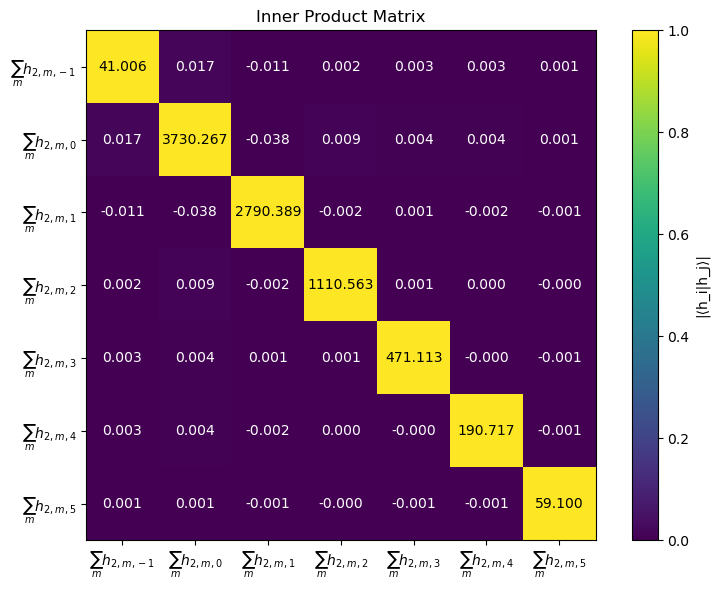

In [37]:
# Display as heatmap
labels = [                                                                                                                                                                                       
    r'$\sum_m h_{2,m,-1}$',                                                      
    r'$\sum_m h_{2,m,0}$',                                                                                                                                                                         
    r'$\sum_m h_{2,m,1}$',                                                                                                                                                                         
    r'$\sum_m h_{2,m,2}$',                                                                                                                                                                         
    r'$\sum_m h_{2,m,3}$',                                                                                                                                                                         
    r'$\sum_m h_{2,m,4}$',                                                                                                                                                                       
    r'$\sum_m h_{2,m,5}$',
]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(inner_product_matrix, cmap='viridis', vmin=0, vmax=1)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
plt.colorbar(im, label='|⟨h_i|h_j⟩|')
ax.set_title('Inner Product Matrix')

# Annotate cells with values
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{inner_product_matrix[i, j]:.3f}',
                ha='center', va='center', color='white' if inner_product_matrix[i, j] < 0.5 else 'black')

plt.tight_layout()
plt.show()


In [38]:
inner_product_matrix

array([[ 4.10064832e+01,  1.66084914e-02, -1.10466988e-02,
         1.67164246e-03,  2.85397423e-03,  3.00935338e-03,
         7.93251886e-04],
       [ 1.66084914e-02,  3.73026693e+03, -3.84709101e-02,
         8.83643720e-03,  4.27711750e-03,  4.09665346e-03,
         7.66041084e-04],
       [-1.10466988e-02, -3.84709101e-02,  2.79038920e+03,
        -1.99245157e-03,  6.16426916e-04, -2.14970028e-03,
        -1.31558707e-03],
       [ 1.67164246e-03,  8.83643720e-03, -1.99245157e-03,
         1.11056268e+03,  1.09554656e-03,  2.16355931e-05,
        -4.72114787e-04],
       [ 2.85397423e-03,  4.27711750e-03,  6.16426916e-04,
         1.09554656e-03,  4.71112735e+02, -7.29886379e-05,
        -5.09000654e-04],
       [ 3.00935338e-03,  4.09665346e-03, -2.14970028e-03,
         2.16355931e-05, -7.29886379e-05,  1.90716506e+02,
        -5.91880762e-04],
       [ 7.93251886e-04,  7.66041084e-04, -1.31558707e-03,
        -4.72114787e-04, -5.09000654e-04, -5.91880762e-04,
         5.9100483

In [39]:
h2_f = gwf.freq_wave(h_2)

gwf.inner(h2_f, h2_f)

array(1110.56267844)

In [40]:
h3_f = gwf.freq_wave(h_3)

gwf.inner(h3_f, h3_f)

array(471.11273473)

In [41]:
h4_f = gwf.freq_wave(h_4)

gwf.inner(h4_f, h4_f)

array(190.71650569)

In [42]:
overlap_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        hi_f = gwf.freq_wave(waveforms[i])
        hj_f = gwf.freq_wave(waveforms[j])
        overlap_matrix[i,j] = gwf.overlap(hi_f, hj_f)



In [43]:
overlap_matrix


array([[ 1.00000000e+00,  4.24652777e-05, -3.26568176e-05,
         7.83331504e-06,  2.05334234e-05,  3.40292820e-05,
         1.61134797e-05],
       [ 4.24652777e-05,  1.00000000e+00, -1.19242237e-05,
         4.34145899e-06,  3.22640442e-06,  4.85696677e-06,
         1.63149817e-06],
       [-3.26568176e-05, -1.19242237e-05,  1.00000000e+00,
        -1.13183689e-06,  5.37634068e-07, -2.94680489e-06,
        -3.23960223e-06],
       [ 7.83331504e-06,  4.34145899e-06, -1.13183689e-06,
         1.00000000e+00,  1.51459626e-06,  4.70113937e-08,
        -1.84280996e-06],
       [ 2.05334234e-05,  3.22640442e-06,  5.37634068e-07,
         1.51459626e-06,  1.00000000e+00, -2.43499849e-07,
        -3.05042536e-06],
       [ 3.40292820e-05,  4.85696677e-06, -2.94680489e-06,
         4.70113937e-08, -2.43499849e-07,  1.00000000e+00,
        -5.57499610e-06],
       [ 1.61134797e-05,  1.63149817e-06, -3.23960223e-06,
        -1.84280996e-06, -3.05042536e-06, -5.57499610e-06,
         1.0000000

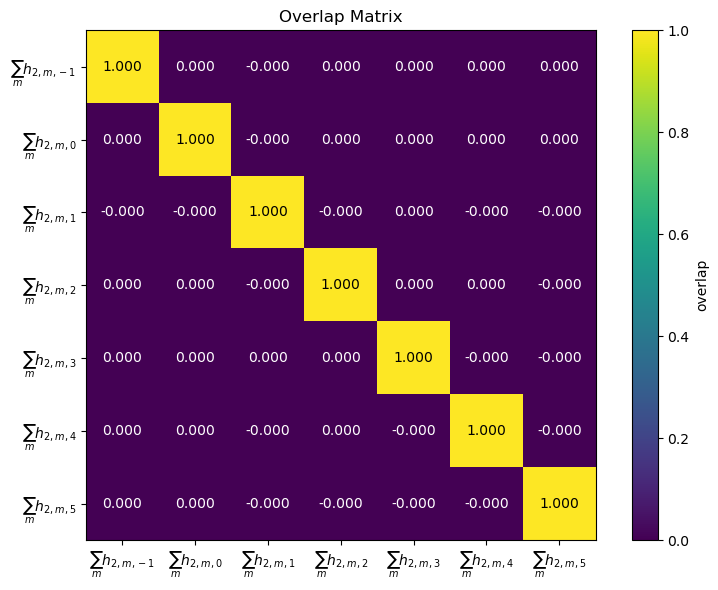

In [44]:


fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(overlap_matrix, cmap='viridis', vmin=0, vmax=1)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
plt.colorbar(im, label='overlap')
ax.set_title('Overlap Matrix')

# Annotate cells with values
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{overlap_matrix[i, j]:.3f}',
                ha='center', va='center', color='white' if overlap_matrix[i, j] < 0.5 else 'black')

plt.tight_layout()
plt.show()
